<a href="https://colab.research.google.com/github/akemitti/Pred-inad-credito/blob/main/notebook06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06 — Integração do Índice de Sentimento com a Previsão de Inadimplência

**Objetivo**: Integrar os 4 melhores índices de sentimento selecionados no Notebook 05 como features exógenas ao melhor modelo preditivo identificado no Notebook 02, avaliando o ganho de desempenho em relação ao modelo base.

---

## Contexto: Resultados dos Notebooks Anteriores

### Notebook 05 — Ranking Final dos Modelos de Sentimento (Atas do COPOM)

| Rank | Modelo | Fonte | Pearson r | Spearman r | \|Pearson r\| | Lag Ótimo |
|:----:|--------|:-----:|:---------:|:----------:|:------------:|:---------:|
| 🥇 1 | **Mistral** | COPOM | -0.5468 | -0.5542 | **0.5468** | **6 meses** |
| 🥈 2 | **NLTK/VADER** | COPOM | +0.4699 | +0.4916 | **0.4699** | **1 mês** |
| 🥉 3 | **Média dos Modelos** | COPOM | -0.4132 | -0.3708 | **0.4132** | **6 meses** |
| 4 | **BERT Multilingual** | COPOM | +0.2701 | +0.2385 | **0.2701** | **6 meses** |

> **Leitura dos resultados:**
> - **Mistral (lag=6, r=−0.547):** sinal negativo com maior antecedência — sentimento mais pessimista nas atas do COPOM precede aumento da inadimplência em ~6 meses. Feature com maior poder preditivo.
> - **NLTK/VADER (lag=1, r=+0.470):** correlação positiva de curto prazo — possivelmente captura fase do ciclo econômico. Sinal complementar ao Mistral.
> - **Média dos Modelos (lag=6, r=−0.413):** indicador sintético que agrega os scores dos 5 modelos de PLN, com sinal negativo de médio prazo.
> - **BERT Multilingual (lag=6, r=+0.270):** sinal moderado de médio prazo, alinhado com o horizonte H=3 do modelo mas com defasagem de 6 meses.
> - Os lags já estão aplicados nas colunas exportadas pelo NB05 — cada coluna de sentimento entra diretamente no XGBoost sem shift adicional.

### Notebook 02 — Seleção do Melhor Modelo Preditivo (H=3, walk-forward)

| Modelo | RMSE | MAE | R² | Decisão |
|--------|------|-----|----|:-------:|
| **XGBoost (h=3) + bias** | **↓ menor** | **↓ menor** | **↑ maior** | ✅ **SELECIONADO** |
| SVR (h=3) + bias | médio | médio | médio | — |
| ARIMAX (h=3) + bias | ↑ maior | ↑ maior | ↓ menor | — |

> **XGBoost** vence em todas as métricas na tabela consolidada do NB02. A mesma arquitetura é mantida aqui: previsão direta H=3, walk-forward expansivo, bias correction.

---
**Inputs:** `base_series.csv` (NB01) · `base_sentimento_selecionado.csv` (NB05)  
**Output:** `base_modelo_final.csv` · métricas comparativas · visualizações

## 1. Instalação e Importações

In [1]:
%pip install pandas numpy matplotlib statsmodels scikit-learn xgboost seaborn scipy --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ── Paleta visual ────────────────────────────────────────────────────────────
COLOR_BASE  = "#aec7e8"   # azul claro  → modelo base
COLOR_SENT  = "#0e5764"   # azul escuro → modelo + sentimento
COLOR_REAL  = "#d62728"   # vermelho    → série realizada
COLOR_MIST  = "#2ca02c"   # verde       → Mistral (top-1)
COLOR_NLTK  = "#ff7f0e"   # laranja     → NLTK/VADER (top-2)
COLOR_MEDIA = "#9467bd"   # roxo        → Média dos Modelos (top-3)
COLOR_BERT  = "#8c564b"   # marrom      → BERT Multilingual (top-4)

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
SEED = 42
np.random.seed(SEED)

# Nota: os lags ótimos já estão embutidos nos nomes das colunas exportadas
# pelo NB05 (ex: sent_copom_mistral_lag6). Não é necessário aplicar shift
# adicional — cada coluna entra diretamente como feature no XGBoost.

print('✅ Importações concluídas')

✅ Importações concluídas


## 2. Funções Auxiliares (padrão Notebook 02)

In [3]:
def metricas_regr(y_true, y_pred) -> dict:
    """MAE, RMSE, R², Bias e reta pred~obs — idêntico ao Notebook 02."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    bias = float(np.mean(np.array(y_true) - np.array(y_pred)))
    lr   = LinearRegression().fit(np.array(y_true).reshape(-1, 1), np.array(y_pred))
    return {
        "MAE":             round(mae,  6),
        "RMSE":            round(rmse, 6),
        "R2":              round(r2,   6),
        "Bias (obs-prev)": round(bias, 6),
        "Slope pred~obs":  round(float(lr.coef_[0]), 6),
        "Intercept":       round(float(lr.intercept_), 6),
    }


def walk_forward_xgb(X: pd.DataFrame, y: pd.Series, train_size: int) -> pd.Series:
    """
    Walk-forward expansivo — replica exatamente a função do Notebook 02.
    Treina em X[:i] e prevê X[i] para todo i em [train_size, len(X)).
    """
    preds, idxs = [], []
    for i in range(train_size, len(X)):
        m = XGBRegressor(
            n_estimators=400, max_depth=3, learning_rate=0.05,
            subsample=0.9,    colsample_bytree=0.9,
            random_state=SEED, objective="reg:squarederror", verbosity=0
        )
        m.fit(X.iloc[:i], y.iloc[:i])
        preds.append(float(m.predict(X.iloc[[i]])[0]))
        idxs.append(X.index[i])
    return pd.Series(preds, index=idxs)


def plot_scatter_regressao(ax, y_true, y_pred, titulo, cor):
    """Scatter previsto vs observado com reta ajustada — padrão NB02."""
    df_ = pd.concat([y_true.rename("obs"), y_pred.rename("pred")], axis=1).dropna()
    lr  = LinearRegression().fit(df_[["obs"]], df_["pred"])
    r2  = lr.score(df_[["obs"]], df_["pred"])
    xy  = [min(df_.min()), max(df_.max())]
    xx  = np.linspace(xy[0], xy[1], 100)
    ax.scatter(df_["obs"], df_["pred"], s=30, alpha=0.7, color=cor, edgecolors="none")
    ax.plot(xy, xy, "--", lw=1.5, alpha=0.35, color=cor, label="45° (ideal)")
    ax.plot(xx, lr.predict(xx.reshape(-1, 1)), lw=2.0, color=cor,
            label=f"fit: {lr.coef_[0][0]:.3f}·obs + {lr.intercept_[0]:.3f}")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Observado"); ax.set_ylabel("Previsto")
    ax.text(0.03, 0.97, f"$R^2$={r2:.4f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=10, color=cor)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, alpha=0.25)

print('✅ Funções definidas')

✅ Funções definidas


## 3. Carregamento dos Dados

In [4]:
# ── 3.1 Série Inadimplencia (Notebook 01) ──────────────────────────────────
URL_SERIES = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_series.csv"
try:
    df_macro = pd.read_csv("base_series.csv", index_col=0)
    print("✅ base_series.csv carregado do disco.")
except FileNotFoundError:
    df_macro = pd.read_csv(URL_SERIES, index_col=0)
    print("✅ base_series.csv carregado do GitHub.")

df_macro.columns = [c.strip().lower() for c in df_macro.columns]
df_macro["data"]  = pd.to_datetime(df_macro["data"], errors="coerce")
df_macro = (
    df_macro[df_macro["data"] <= "2025-12-31"]
    .sort_values("data").reset_index(drop=True)
)
print(f"Período: {df_macro['data'].min().date()} → {df_macro['data'].max().date()}")
print(f"Colunas: {list(df_macro.columns)}")
display(df_macro.head(3))

✅ base_series.csv carregado do GitHub.
Período: 2019-01-01 → 2025-12-01
Colunas: ['data', 'inad_total', 'saldo_total', 'concessao_total', 'juros_total', 'ipca', 'selic']


,data,inad_total,saldo_total,concessao_total,juros_total,ipca,selic
0,2019-01-01,2.95,3237076.0,284019.0,24.46,0.32,6.5
1,2019-02-01,2.91,3247396.0,284219.0,24.79,0.43,6.5
2,2019-03-01,2.99,3273000.0,297678.0,25.07,0.75,6.5


In [5]:
# ── 3.2 Scores dos Top-4 Modelos de Sentimento (Notebook 05) ─────────────────
URL_SENT = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_sentimento_selecionado.csv"
try:
    df_sent = pd.read_csv("base_sentimento_selecionado.csv")
    print("✅ base_sentimento_selecionado.csv carregado do disco.")
except FileNotFoundError:
    df_sent = pd.read_csv(URL_SENT)
    print("✅ base_sentimento_selecionado.csv carregado do GitHub.")

df_sent

✅ base_sentimento_selecionado.csv carregado do GitHub.


,data,inad_total,sent_copom_mistral_lag6,sent_copom_nltk_vader_lag1,sent_copom_média_dos_modelos_lag6,sent_copom_bert_multilingual_lag6
0,2019-07-01,3.06,0.500,-0.77830,-0.119692,-0.071429
1,2019-08-01,3.04,0.500,-0.84020,-0.119692,-0.071429
2,2019-09-01,3.06,0.500,-0.86045,-0.115943,-0.062500
3,2019-10-01,3.03,0.575,-0.88070,-0.130848,-0.093750
4,2019-11-01,3.00,0.650,-0.84020,-0.145753,-0.125000
...,...,...,...,...,...,...
73,2025-08-01,3.95,-0.700,-0.68080,-0.379278,-0.093750
74,2025-09-01,3.91,-0.700,-0.68080,-0.431325,-0.125000
75,2025-10-01,4.00,-0.700,-0.68080,-0.412255,-0.093750
76,2025-11-01,4.01,-0.700,-0.68080,-0.393185,-0.062500


In [6]:
# Padronizar nomes das colunas
df_sent.columns = [c.strip().lower() for c in df_sent.columns]

# Identificar coluna de data
col_data_sent = "data" if "data" in df_sent.columns else "mes"

# Criar coluna mensal
df_sent["mes"] = pd.to_datetime(df_sent[col_data_sent], errors="coerce")

# Colunas de sentimento selecionadas no Notebook 05
# Agora considerando os 4 melhores modelos selecionados
COL_MISTRAL = "sent_copom_mistral_lag6"
COL_NLTK    = "sent_copom_nltk_vader_lag1"
COL_MEDIA   = "sent_copom_média_dos_modelos_lag6"
COL_BERT    = "sent_copom_bert_multilingual_lag6"

sent_cols = [
    COL_MISTRAL,
    COL_NLTK,
    COL_MEDIA,
    COL_BERT
]

# Validar se todas as colunas esperadas existem na base
for col in sent_cols:
    if col not in df_sent.columns:
        raise KeyError(
            f"Coluna '{col}' não encontrada. "
            f"Colunas disponíveis: {list(df_sent.columns)}"
        )

print(
    f"Sentimento — {len(df_sent)} obs | "
    f"{df_sent['mes'].min().date()} → {df_sent['mes'].max().date()}"
)

print(f"Colunas selecionadas para o Notebook 06: {sent_cols}")

display(
    df_sent[
        ["mes", "inad_total"] + sent_cols
    ].head(4)
)

Sentimento — 78 obs | 2019-07-01 → 2025-12-01
Colunas selecionadas para o Notebook 06: ['sent_copom_mistral_lag6', 'sent_copom_nltk_vader_lag1', 'sent_copom_média_dos_modelos_lag6', 'sent_copom_bert_multilingual_lag6']


,mes,inad_total,sent_copom_mistral_lag6,sent_copom_nltk_vader_lag1,sent_copom_média_dos_modelos_lag6,sent_copom_bert_multilingual_lag6
0,2019-07-01,3.06,0.500,-0.77830,-0.119692,-0.071429
1,2019-08-01,3.04,0.500,-0.84020,-0.119692,-0.071429
2,2019-09-01,3.06,0.500,-0.86045,-0.115943,-0.062500
3,2019-10-01,3.03,0.575,-0.88070,-0.130848,-0.093750


## 4. Construção do Dataset


In [7]:
# ── 5.1 Garantir coluna mensal nas duas bases ────────────────────────────────

# Padronizar nomes das colunas
df_macro.columns = [c.strip().lower() for c in df_macro.columns]
df_sent.columns  = [c.strip().lower() for c in df_sent.columns]

# Criar/padronizar coluna 'mes' na base macroeconômica
if "mes" in df_macro.columns:
    df_macro["mes"] = pd.to_datetime(df_macro["mes"], errors="coerce")
elif "data" in df_macro.columns:
    df_macro["mes"] = pd.to_datetime(df_macro["data"], errors="coerce")
else:
    raise KeyError(
        f"Nem 'mes' nem 'data' foram encontradas em df_macro. "
        f"Colunas disponíveis: {list(df_macro.columns)}"
    )

# Criar/padronizar coluna 'mes' na base de sentimento
if "mes" in df_sent.columns:
    df_sent["mes"] = pd.to_datetime(df_sent["mes"], errors="coerce")
elif "data" in df_sent.columns:
    df_sent["mes"] = pd.to_datetime(df_sent["data"], errors="coerce")
else:
    raise KeyError(
        f"Nem 'mes' nem 'data' foram encontradas em df_sent. "
        f"Colunas disponíveis: {list(df_sent.columns)}"
    )

# Garantir que ambas estejam no primeiro dia do mês
df_macro["mes"] = df_macro["mes"].dt.to_period("M").dt.to_timestamp()
df_sent["mes"]  = df_sent["mes"].dt.to_period("M").dt.to_timestamp()

# Evitar duplicidade mensal na base de sentimento
df_sent_merge = (
    df_sent[["mes"] + sent_cols]
    .drop_duplicates(subset=["mes"])
    .sort_values("mes")
    .reset_index(drop=True)
)

# Datas de início e fim disponíveis na base de sentimento
data_inicio_sent = df_sent_merge["mes"].min()
data_fim_sent    = df_sent_merge["mes"].max()

print(f"Período disponível na base de sentimento: {data_inicio_sent.date()} → {data_fim_sent.date()}")


# ── 5.2 Merge: base macroeconômica + sentimentos selecionados ────────────────
# merge = junção de tabelas pela coluna 'mes'

df = df_macro.merge(
    df_sent_merge,
    on="mes",
    how="left"
).sort_values("mes").reset_index(drop=True)

print("Merge realizado com sucesso.")
print(f"df_macro: {df_macro['mes'].min().date()} → {df_macro['mes'].max().date()} | {len(df_macro)} linhas")
print(f"df_sent:  {df_sent_merge['mes'].min().date()} → {df_sent_merge['mes'].max().date()} | {len(df_sent_merge)} linhas")
print(f"df final antes do recorte: {df['mes'].min().date()} → {df['mes'].max().date()} | {len(df)} linhas")

# ── df_model: dataset completo com todas as features de sentimento ───────────
# Todos os modelos utilizam df_model para garantir conjunto de avaliação idêntico.
df_model = df.copy()

print(f"df_model: {df_model['mes'].min().date()} → {df_model['mes'].max().date()} | {len(df_model)} linhas")

Período disponível na base de sentimento: 2019-07-01 → 2025-12-01
Merge realizado com sucesso.
df_macro: 2019-01-01 → 2025-12-01 | 84 linhas
df_sent:  2019-07-01 → 2025-12-01 | 78 linhas
df final antes do recorte: 2019-01-01 → 2025-12-01 | 84 linhas
df_model: 2019-01-01 → 2025-12-01 | 84 linhas


In [8]:
SPLIT_DATE = "01/01/2023"   # idêntico ao Notebook 02
SPLIT_TS   = pd.to_datetime(SPLIT_DATE, dayfirst=True)
print(f"Split: treino < {SPLIT_TS.date()} | teste ≥ {SPLIT_TS.date()}")

Split: treino < 2023-01-01 | teste ≥ 2023-01-01


In [9]:
# ── Criação do target e definição das features macro ────────────────────────

# Target: inadimplência daqui a 3 meses (H=3) — idêntico ao Notebook 02
df["target_h3"] = df["inad_total"].shift(-3)
df_model["target_h3"] = df_model["inad_total"].shift(-3)

# Features macroeconômicas — todas as colunas numéricas exceto target, datas e sentimento
_nao_feats = {"data", "mes", "inad_total", "target_h3"} | set(sent_cols)
MACRO_FEATS = [c for c in df_model.columns if c not in _nao_feats]

print(f"Features macro ({len(MACRO_FEATS)}): {MACRO_FEATS}")
print(f"Target criado — NaNs ao final (esperado H=3): {df_model['target_h3'].isna().sum()}")

# ── Índice compartilhado — linhas válidas para TODOS os modelos ───────────────
# Garante que todos os modelos (base e com sentimento) sejam avaliados
# exatamente nas mesmas observações, eliminando risco de dropna() seletivo
# dentro da função rodar_modelo().
ALL_FEATS = MACRO_FEATS + [COL_NLTK, COL_MISTRAL, COL_MEDIA, COL_BERT]
cols_avaliacao = ALL_FEATS + ["target_h3", "data"]

idx_valido = df_model[cols_avaliacao].dropna().index
df_model = df_model.loc[idx_valido].reset_index(drop=True)

print(f"\nÍndice compartilhado: {len(df_model)} linhas válidas para todos os modelos")
print(f"Período: {df_model['data'].min().date()} → {df_model['data'].max().date()}")

# Verificar ausência de NaN nas colunas de avaliação
nulos = df_model[cols_avaliacao].isna().sum()
if nulos.sum() == 0:
    print("✅ Nenhum NaN nas colunas de avaliação — comparação totalmente justa.")
else:
    print("⚠️ NaNs remanescentes:", nulos[nulos > 0].to_dict())

Features macro (5): ['saldo_total', 'concessao_total', 'juros_total', 'ipca', 'selic']
Target criado — NaNs ao final (esperado H=3): 3

Índice compartilhado: 75 linhas válidas para todos os modelos
Período: 2019-07-01 → 2025-09-01
✅ Nenhum NaN nas colunas de avaliação — comparação totalmente justa.


## 5. XGBoost — Modelo Base (sem sentimento)
Replicação exata do modelo vencedor do Notebook 02.

In [10]:
def rodar_modelo(nome, feats, df_full, split_ts, h=3):
    """
    Prepara dataset, roda walk-forward, aplica bias correction e retorna
    dicionário com métricas, previsões e datas — pronto para comparação.

    Nota: df_full já chegou filtrado pelo índice compartilhado (sem NaN
    nas colunas de avaliação), portanto o dropna() aqui seleciona apenas
    as colunas necessárias sem alterar o conjunto de linhas avaliadas.
    """
    cols_necessarias = feats + ["target_h3", "data"]
    df_m = df_full[cols_necessarias].dropna().reset_index(drop=True)

    train_size = (df_m["data"] < split_ts).sum()
    if train_size < 5:
        raise ValueError(f"[{nome}] treino insuficiente: {train_size} obs")

    X = df_m[feats]
    y = df_m["target_h3"]

    print(f"  ⏳ {nome} — treino: {train_size} | teste: {len(df_m)-train_size} obs")
    yhat = walk_forward_xgb(X, y, train_size)
    y_true = y.loc[yhat.index]

    bias    = (y_true - yhat).mean()
    yhat_bc = yhat + bias

    metr    = metricas_regr(y_true, yhat)
    metr_bc = metricas_regr(y_true, yhat_bc)

    return {
        "nome":     nome,
        "feats":    feats,
        "datas":    df_m.loc[yhat.index, "data"],
        "y_true":   y_true,
        "yhat":     yhat,
        "yhat_bc":  yhat_bc,
        "bias":     bias,
        "metr":     metr,
        "metr_bc":  metr_bc,
    }

print("=" * 55)
print("  MODELO 1 — XGBoost Base (sem sentimento)")
print("=" * 55)

res_base = rodar_modelo(
    nome     = "XGBoost Base",
    feats    = MACRO_FEATS,
    df_full  = df_model,
    split_ts = SPLIT_TS,
)

print(f"\n── Sem bias correction:")
display(pd.DataFrame([res_base["metr"]], index=["XGBoost Base (h=3)"]))
print(f"── Com bias correction (Δbias={res_base['bias']:+.4f}):")
display(pd.DataFrame([res_base["metr_bc"]], index=["XGBoost Base (h=3) + bias"]))

  MODELO 1 — XGBoost Base (sem sentimento)
  ⏳ XGBoost Base — treino: 42 | teste: 33 obs

── Sem bias correction:


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost Base (h=3),0.106262,0.14678,0.73386,0.085775,0.890797,0.289253


── Com bias correction (Δbias=+0.0858):


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost Base (h=3) + bias,0.077295,0.11911,0.824746,0.0,0.890797,0.375028


## 6. XGBoost + NLTK/VADER
Adiciona o score do NLTK/VADER (lag=1 mês, |r|=0.4699) às features macro.

In [11]:
print("=" * 55)
print("  MODELO 2 — XGBoost + NLTK/VADER (lag=1, |r|=0.4699)")
print("=" * 55)

res_nltk = rodar_modelo(
    nome    = "XGBoost+NLTK",
    feats   = MACRO_FEATS + [COL_NLTK],
    df_full  = df_model,
    split_ts = SPLIT_TS,
)

print(f"\n── Sem bias correction:")
display(pd.DataFrame([res_nltk["metr"]], index=["XGBoost+NLTK (h=3)"]))
print(f"── Com bias correction (Δbias={res_nltk['bias']:+.4f}):")
display(pd.DataFrame([res_nltk["metr_bc"]], index=["XGBoost+NLTK (h=3) + bias"]))

  MODELO 2 — XGBoost + NLTK/VADER (lag=1, |r|=0.4699)
  ⏳ XGBoost+NLTK — treino: 42 | teste: 33 obs

── Sem bias correction:


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+NLTK (h=3),0.099835,0.134895,0.775214,0.062719,0.825393,0.536925


── Com bias correction (Δbias=+0.0627):


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+NLTK (h=3) + bias,0.082192,0.119428,0.823807,0.0,0.825393,0.599644


## 7. XGBoost + Mistral
Adiciona o score do Mistral (lag=6 meses, |r|=0.5468) às features macro.

In [12]:
print("=" * 55)
print("  MODELO 3 — XGBoost + Mistral (lag=6, |r|=0.5468)")
print("=" * 55)

res_mist = rodar_modelo(
    nome    = "XGBoost+Mistral",
    feats   = MACRO_FEATS + [COL_MISTRAL],
    df_full  = df_model,
    split_ts = SPLIT_TS,
)

print(f"\n── Sem bias correction:")
display(pd.DataFrame([res_mist["metr"]], index=["XGBoost+Mistral (h=3)"]))
print(f"── Com bias correction (Δbias={res_mist['bias']:+.4f}):")
display(pd.DataFrame([res_mist["metr_bc"]], index=["XGBoost+Mistral (h=3) + bias"]))

  MODELO 3 — XGBoost + Mistral (lag=6, |r|=0.5468)
  ⏳ XGBoost+Mistral — treino: 42 | teste: 33 obs

── Sem bias correction:


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+Mistral (h=3),0.105053,0.153718,0.708108,0.0726,0.822091,0.538382


── Com bias correction (Δbias=+0.0726):


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+Mistral (h=3) + bias,0.086731,0.135493,0.773217,-0.0,0.822091,0.610982


## 8. XGBoost + BERT Multilingual
Adiciona o score do BERT Multilingual (lag=6 meses, |r|=0.2701) às features macro.

In [13]:
print("=" * 55)
print("  MODELO 5 — XGBoost + BERT Multilingual (lag=6, |r|=0.2701)")
print("=" * 55)

res_bert = rodar_modelo(
    nome     = "XGBoost+BERT",
    feats    = MACRO_FEATS + [COL_BERT],
    df_full  = df_model,
    split_ts = SPLIT_TS,
)

print(f"\n── Sem bias correction:")
display(pd.DataFrame([res_bert["metr"]], index=["XGBoost+BERT (h=3)"]))

print(f"── Com bias correction (Δbias={res_bert['bias']:+.4f}):")
display(pd.DataFrame([res_bert["metr_bc"]], index=["XGBoost+BERT (h=3) + bias"]))

  MODELO 5 — XGBoost + BERT Multilingual (lag=6, |r|=0.2701)
  ⏳ XGBoost+BERT — treino: 42 | teste: 33 obs

── Sem bias correction:


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+BERT (h=3),0.090096,0.13119,0.787393,0.05852,0.838326,0.496707


── Com bias correction (Δbias=+0.0585):


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+BERT (h=3) + bias,0.077022,0.117415,0.829698,0.0,0.838326,0.555227


## 9. XGBoost + Média dos Modelos

Nesta etapa, é incorporada ao modelo XGBoost a variável de sentimento correspondente à **média dos modelos**, com defasagem de **6 meses**.

Essa variável representa um indicador agregado dos scores de sentimento extraídos das Atas do Copom, combinando diferentes abordagens de PLN — Processamento de Linguagem Natural — em uma única medida sintética.

A inclusão dessa variável permite avaliar se um score médio, menos dependente das particularidades de um único modelo de sentimento, contribui para melhorar a predição da inadimplência em relação ao modelo base com variáveis macroeconômicas.

Na etapa de correlação do Notebook 05, a Média dos Modelos apresentou correlação de Pearson de **-0,4132** com a inadimplência, em valor absoluto de **0,4132**, considerando lag de **6 meses**.

In [14]:
print("=" * 55)
print("  MODELO 4 — XGBoost + Média dos Modelos (lag=6, |r|=0.4132)")
print("=" * 55)

res_media = rodar_modelo(
    nome     = "XGBoost+MediaModelos",
    feats    = MACRO_FEATS + [COL_MEDIA],
    df_full  = df_model,
    split_ts = SPLIT_TS,
)

print(f"\n── Sem bias correction:")
display(pd.DataFrame([res_media["metr"]], index=["XGBoost+Média dos Modelos (h=3)"]))

print(f"── Com bias correction (Δbias={res_media['bias']:+.4f}):")
display(pd.DataFrame([res_media["metr_bc"]], index=["XGBoost+Média dos Modelos (h=3) + bias"]))

  MODELO 4 — XGBoost + Média dos Modelos (lag=6, |r|=0.4132)
  ⏳ XGBoost+MediaModelos — treino: 42 | teste: 33 obs

── Sem bias correction:


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+Média dos Modelos (h=3),0.1047,0.150499,0.720205,0.073093,0.822371,0.536929


── Com bias correction (Δbias=+0.0731):


,MAE,RMSE,R2,Bias (obs-prev),Slope pred~obs,Intercept
XGBoost+Média dos Modelos (h=3) + bias,0.083471,0.131557,0.786202,-0.0,0.822371,0.610021


## 10. Tabela Comparativa de Ganho — Todos os Modelos

In [15]:
# Referência: métricas do modelo base com bias correction
rmse_ref = res_base["metr_bc"]["RMSE"]
mae_ref  = res_base["metr_bc"]["MAE"]
r2_ref   = res_base["metr_bc"]["R2"]

todos = [
    ("XGBoost Base (NB02)",                         res_base,  "—"),
    ("XGBoost + NLTK/VADER (lag=1)",                res_nltk,  "0.4699"),
    ("XGBoost + Mistral (lag=6)",                   res_mist,  "0.5468"),
    ("XGBoost + Média dos Modelos (lag=6)",         res_media, "0.4132"),
    ("XGBoost + BERT Multilingual (lag=6)",         res_bert,  "0.2701"),
]  # Todos avaliados sobre df_model — conjunto de teste idêntico

linhas = []

for label, res, corr in todos:
    m = res["metr_bc"]

    rmse = m["RMSE"]
    mae  = m["MAE"]
    r2   = m["R2"]

    d_rmse = (rmse_ref - rmse) / rmse_ref * 100
    d_mae  = (mae_ref  - mae)  / mae_ref  * 100
    d_r2   = r2 - r2_ref

    linhas.append({
        "Modelo":          label,
        "|Pearson r| NB05": corr,
        "RMSE":            round(rmse, 6),
        "MAE":             round(mae,  6),
        "R2":              round(r2,   6),
        "ΔRMSE (%)":       f"{d_rmse:+.2f}%" if corr != "—" else "—",
        "ΔMAE (%)":        f"{d_mae:+.2f}%"  if corr != "—" else "—",
        "ΔR²":             f"{d_r2:+.4f}"    if corr != "—" else "—",
    })

df_comp = pd.DataFrame(linhas).set_index("Modelo")

print("=" * 90)
print("   TABELA COMPARATIVA — XGBoost Base vs. XGBoost + Sentimento (com bias correction)")
print("=" * 90)

display(df_comp)

# Melhor modelo pelo menor RMSE
melhor_rmse = min(todos, key=lambda x: x[1]["metr_bc"]["RMSE"])

print(
    f"\n🏆 Melhor RMSE: {melhor_rmse[0]} "
    f"→ RMSE={melhor_rmse[1]['metr_bc']['RMSE']:.6f}"
)

   TABELA COMPARATIVA — XGBoost Base vs. XGBoost + Sentimento (com bias correction)


,|Pearson r| NB05,RMSE,MAE,R2,ΔRMSE (%),ΔMAE (%),ΔR²
Modelo,,,,,,,
XGBoost Base (NB02),—,0.119110,0.077295,0.824746,—,—,—
XGBoost + NLTK/VADER (lag=1),0.4699,0.119428,0.082192,0.823807,-0.27%,-6.34%,-0.0009
XGBoost + Mistral (lag=6),0.5468,0.135493,0.086731,0.773217,-13.75%,-12.21%,-0.0515
XGBoost + Média dos Modelos (lag=6),0.4132,0.131557,0.083471,0.786202,-10.45%,-7.99%,-0.0385
XGBoost + BERT Multilingual (lag=6),0.2701,0.117415,0.077022,0.829698,+1.42%,+0.35%,+0.0050



🏆 Melhor RMSE: XGBoost + BERT Multilingual (lag=6) → RMSE=0.117415


## 11. Visualizações
### 11.1 Série Temporal — Todos os Modelos vs. Observado

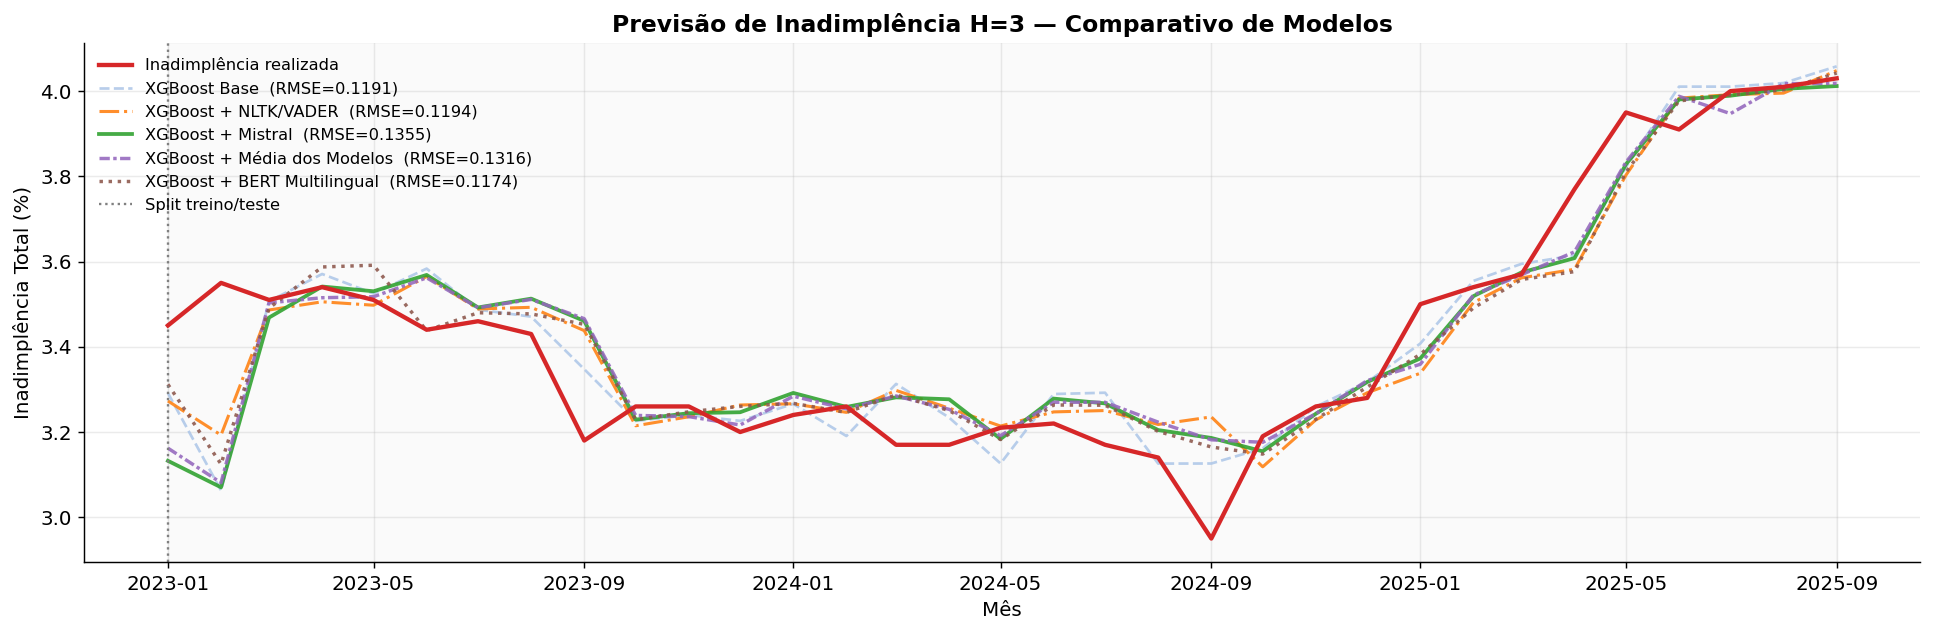

In [16]:
COLOR_MEDIA = "#9467bd"

fig, ax = plt.subplots(figsize=(15, 5))

# Série realizada, usando a do modelo base como referência
ax.plot(
    res_base["datas"].values,
    res_base["y_true"].values,
    color=COLOR_REAL,
    lw=2.4,
    label="Inadimplência realizada",
    zorder=5
)

# Previsões dos modelos
estilos = [
    (
        res_base,
        "--",
        1.5,
        COLOR_BASE,
        f"XGBoost Base  (RMSE={res_base['metr_bc']['RMSE']:.4f})"
    ),
    (
        res_nltk,
        "-.",
        1.7,
        COLOR_NLTK,
        f"XGBoost + NLTK/VADER  (RMSE={res_nltk['metr_bc']['RMSE']:.4f})"
    ),
    (
        res_mist,
        "-",
        2.1,
        COLOR_MIST,
        f"XGBoost + Mistral  (RMSE={res_mist['metr_bc']['RMSE']:.4f})"
    ),
    (
        res_media,
        (0, (3, 1, 1, 1)),
        1.9,
        COLOR_MEDIA,
        f"XGBoost + Média dos Modelos  (RMSE={res_media['metr_bc']['RMSE']:.4f})"
    ),
    (
        res_bert,
        ":",
        1.9,
        COLOR_BERT,
        f"XGBoost + BERT Multilingual  (RMSE={res_bert['metr_bc']['RMSE']:.4f})"
    ),
]

for res, ls, lw, cor, label in estilos:
    ax.plot(
        res["datas"].values,
        res["yhat_bc"].values,
        color=cor,
        lw=lw,
        linestyle=ls,
        label=label,
        alpha=0.88
    )

# Marcação do split treino/teste
ax.axvline(
    SPLIT_TS,
    color="gray",
    linestyle=":",
    lw=1.3,
    label="Split treino/teste"
)

# Área de teste
ymin, ymax = ax.get_ylim()

ax.fill_betweenx(
    [ymin, ymax],
    SPLIT_TS,
    res_base["datas"].max(),
    alpha=0.04,
    color="gray"
)

ax.set_ylim(ymin, ymax)

ax.set_title(
    "Previsão de Inadimplência H=3 — Comparativo de Modelos",
    fontweight="bold",
    fontsize=13
)

ax.set_xlabel("Mês")
ax.set_ylabel("Inadimplência Total (%)")

ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper left"
)

ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()